# LangChain v1 Agents: Complete Guide
## Prerequisites
Make sure you have the required packages installed and Ollama running:
```
pip install -U langchain langchain-community langchain-core langgraph
pip install -U ddgs python-dotenv
```
Local LLM Serving with Ollama:
```
ollama pull qwen3
ollama pull gemma3
```

In [ ]:
# !pip install -U langchain langchain-community langchain-core langgraph
# !pip install -U ddgs python-dotenv

In [ ]:
!pip install langchain langchain-community langchain-core langgraph langchain-ollama ddgs python-dotenv

## 1. Agent with Explicit Model Instance
Full control over model configuration by creating an explicit ChatOllama instance.

## Model Parameters Explained
- temperature: Controls randomness (0.0 = deterministic, 1.0 = very creative)
- num_predict: Maximum tokens to generate (similar to max_tokens in OpenAI)
- top_k: Number of highest probability tokens to consider
- top_p: Cumulative probability threshold for token selection
- repeat_penalty: Penalty for repeating tokens
- num_ctx: Context window size

In [2]:
from langchain_ollama import ChatOllama
from langchain.agents import create_agent
import tools

In [3]:
system_prompt = """You are a helpful AI assistant. 
Use the available tools when needed to answer questions accurately.
If you need to search for information, use the web_search tool.
Always provide clear and concise answers.
"""

In [4]:
print(tools.web_search.invoke({'query': "What is Langchain?", 'num_results': 1}))

Search Results for 'What is Langchain?':


1. **LangChain - Open-source framework for building AI agents - Somi AI**
    5 hours ago·LangChain is an open-source framework that helps developers build applications powered by large language models. It provides modular components for chaining LLM ...
   https://somi.ai/products/lang-chain


## Your First Agent

In [9]:
base_url = "http://localhost:11434"
model_name = 'qwen3:0.6b'

model = ChatOllama(
    base_url=base_url,
    model = model_name,
)

In [10]:
agent = create_agent(model=model, tools=[tools.web_search], system_prompt=system_prompt)

In [11]:
result = agent.invoke({"messages": "What is the top 10 global news right now?"})

In [12]:
result

{'messages': [HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='027e1d93-2dcd-420f-aed3-52511e9a9d05'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-03-10T12:49:13.745295Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2378319000, 'load_duration': 109987375, 'prompt_eval_count': 233, 'prompt_eval_duration': 238243959, 'eval_count': 206, 'eval_duration': 1849265093, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'}, id='lc_run--019cd7cb-4ec1-7ec2-977e-3799198fc735-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news right now', 'num_results': 10}, 'id': 'c33384f2-3ed6-4f3b-96bf-d33e3cca248c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 233, 'output_tokens': 206, 'total_tokens': 439}),
  ToolMessage(content="Search Results for 'top 10 global news right now':\n\n\n1. **Worl

In [13]:
# print(result['messages'][-1].content)
# result['messages'][-1].pretty_print()

Here are the top 10 global news sources as of the latest information:

1. **EL PAÍS (Mexico)**  
   - *Breaking news and current affairs* from around the world, covering politics, business, and culture.  
   - [EL PAÍS](https://www.elpaís.com)

2. **Reuters (Technology)**  
   - *Latest technology news* from every corner of the globe.  
   - [Reuters](https://www.reuters.com/technology/)

3. **Economist (Global News)**  
   - *Real-world news* on topics like business, politics, and global trends.  
   - [Economist](https://www.economist.com/)

4. **TechyDen (Technology News)**  
   - *Top world news stories* and headlines covering technology and innovation.  
   - [TechyDen](https://techyden.com)

5. **DemocracyNow (Global News)**  
   - *Independent global news* from over 1,500 TV/radio stations.  
   - [DemocracyNow](https://freespeech.org/stories)

6. **Global News (Top Headlines)**  
   - *Breaking news* and top headlines from diverse global sources.  
   - [Global News](https://ww

In [14]:
result1 = agent.invoke(result)

In [15]:
result1

{'messages': [HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='027e1d93-2dcd-420f-aed3-52511e9a9d05'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-03-10T12:49:13.745295Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2378319000, 'load_duration': 109987375, 'prompt_eval_count': 233, 'prompt_eval_duration': 238243959, 'eval_count': 206, 'eval_duration': 1849265093, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'}, id='lc_run--019cd7cb-4ec1-7ec2-977e-3799198fc735-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news right now', 'num_results': 10}, 'id': 'c33384f2-3ed6-4f3b-96bf-d33e3cca248c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 233, 'output_tokens': 206, 'total_tokens': 439}),
  ToolMessage(content="Search Results for 'top 10 global news right now':\n\n\n1. **Worl

## Experimenting with Different Settings
Let's compare different model configurations to see how they affect the output:

In [18]:
question = "What is the capital of France? Provide a brief explanation."

model1 = ChatOllama(model=model_name, base_url="http://localhost:11434",
                    temperature=0,
                    top_p=1,
                    repeart_penalty=1.2,
                    num_predict=1000,
                    num_ctx=4096,
                    reasoning=True)

agent1 = create_agent(model=model, tools=[tools.web_search], system_prompt=system_prompt)
result1 = agent1.invoke({"messages": question})

In [19]:
result1

{'messages': [HumanMessage(content='What is the capital of France? Provide a brief explanation.', additional_kwargs={}, response_metadata={}, id='ed6b0d29-a427-45f4-a06f-ecf019fd9f43'),
  AIMessage(content="The capital of France is Paris, which serves as the center of the country. It is the largest city in France and plays a crucial role in the nation's governance, economy, and culture.", additional_kwargs={}, response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-03-10T12:53:38.512943Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1561004500, 'load_duration': 98866125, 'prompt_eval_count': 233, 'prompt_eval_duration': 171802208, 'eval_count': 128, 'eval_duration': 1177371628, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'}, id='lc_run--019cd7cf-5c36-7780-8a3f-536196e14879-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 233, 'output_tokens': 128, 'total_tokens': 361})]}

## 2. Dynamic Model Selection (Qwen3 → Gemma3)
Cost-optimization strategy where the agent automatically switches between models based on conversation complexity.

## Selection Logic
- **< 10 messages**: Use Qwen3 (fast, efficient)
- **≥ 10 messages**: Use Gemma3 (better reasoning, longer context)
## Real-World Applications
- Customer service bots (simple queries → Qwen3, complex issues → Gemma3)
- Research assistants (quick facts → Qwen3, analysis → Gemma3)

In [20]:
# Import required modules
from langchain_ollama import ChatOllama
from langchain.agents import create_agent, AgentState
from langgraph.runtime import Runtime
import tools

# Import the middleware decorator
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

In [26]:
basic_model = ChatOllama(model=model_name, base_url="http://localhost:11434", num_predict=1000)

advanced_model = ChatOllama(model="tinyllama", base_url="http://localhost:11434", num_predict=1000)

@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    message_count = len(request.state["messages"])

    if message_count<3:
        print(f"Using Qwen3 for {message_count} messages")
        request.model = basic_model

    else:
        print(f"Using llama3.2 for {message_count} messages")
        request.model = advanced_model

    return handler(request)

In [27]:
agent = create_agent(model=basic_model, tools = [tools.web_search], system_prompt=system_prompt, middleware=[dynamic_model_selection])

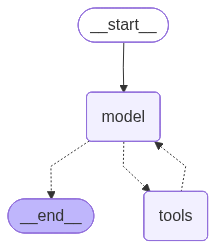

In [28]:
agent

In [29]:
def get_agent_output(messages:list):
    messages = {'messages': messages} # dict
    result = agent.invoke(messages)
    return result

In [ ]:
messages = ["How are you?", "What's the weather in Mumbai today?"]
result = get_agent_output(messages)

In [31]:
result

{'messages': [HumanMessage(content='How are you?', additional_kwargs={}, response_metadata={}, id='fded6e1f-7299-4887-8403-4f57cc649699'),
  HumanMessage(content="What's the weather in Mumbai today?", additional_kwargs={}, response_metadata={}, id='2f24a557-7b65-45f8-a073-cf5065c85121'),
  AIMessage(content="How are you? I'm here to help. The weather in Mumbai today is sunny with a mild temperature. Let me know if you'd like more details!", additional_kwargs={}, response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-03-10T13:00:27.623575Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5048312459, 'load_duration': 106808792, 'prompt_eval_count': 233, 'prompt_eval_duration': 252348708, 'eval_count': 473, 'eval_duration': 4273536833, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'}, id='lc_run--019cd7d5-8cac-7640-badd-59f7e67d1e18-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 233, 'output_tokens': 473, 'total_tokens': 7

# Streaming Agent Responses
## Stream Modes
- "values": Get complete state at each step
- "updates": Get only the changes/updates
- "messages": Get only message updates

In [ ]:
for chunk in agent.stream({'messages':messages}, stream_mode="values"):
    print(chunk['messages'])